In [23]:
#!pip install palmerpenguins
!pip install palmerpenguins

In [24]:
import numpy as np
import pandas as pd
from sys import exit
from palmerpenguins import load_penguins
from plotnine import ggplot, aes, geom_point, geom_bar

0\. Complete the [**check-in** from Section 6.3.2](https://ds-ml-with-python.github.io/Course-Textbook/05-function_writing.html#nested-environments-and-scope): Write a custom function that does the following:

Limit the penguins dataset to a user-chosen species and/or island.
Makes a scatterplot of the penguin bill length and depth.
Try writing a version of this function using dynamic lookup, and a version where everything the function needs is passed in directly

In [25]:
#limit penguins dataset to species and/or island
def limit_penguins(species = None, island = None):
  df = load_penguins()
  if species:
    df = df[df["species"] == species]
  if island:
    df = df[df["island"] == island]
  return df

In [26]:
#scatterplot of penguin bill length + depth
def penguin_plot(species = None, island = None):
    df = load_penguins()

    if species:
        df = df[df["species"] == species]

    if island:
        df = df[df["island"] == island]

    plot = (ggplot(df, aes(x = "bill_length_mm", y = "bill_depth_mm")) + geom_point())

    return plot

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


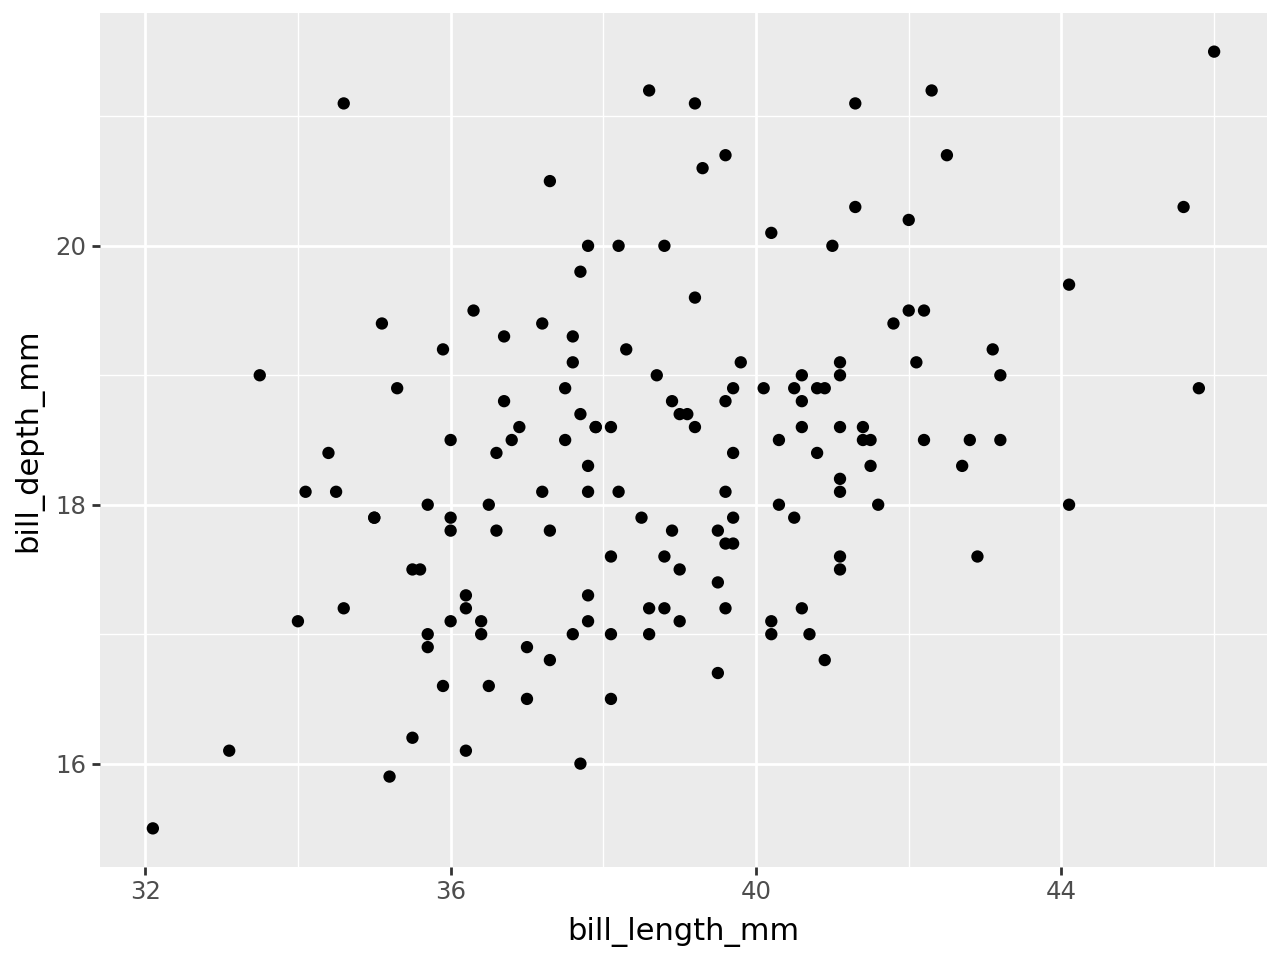

In [27]:
#scatterplot for direct
penguin_plot(species = "Adelie")

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


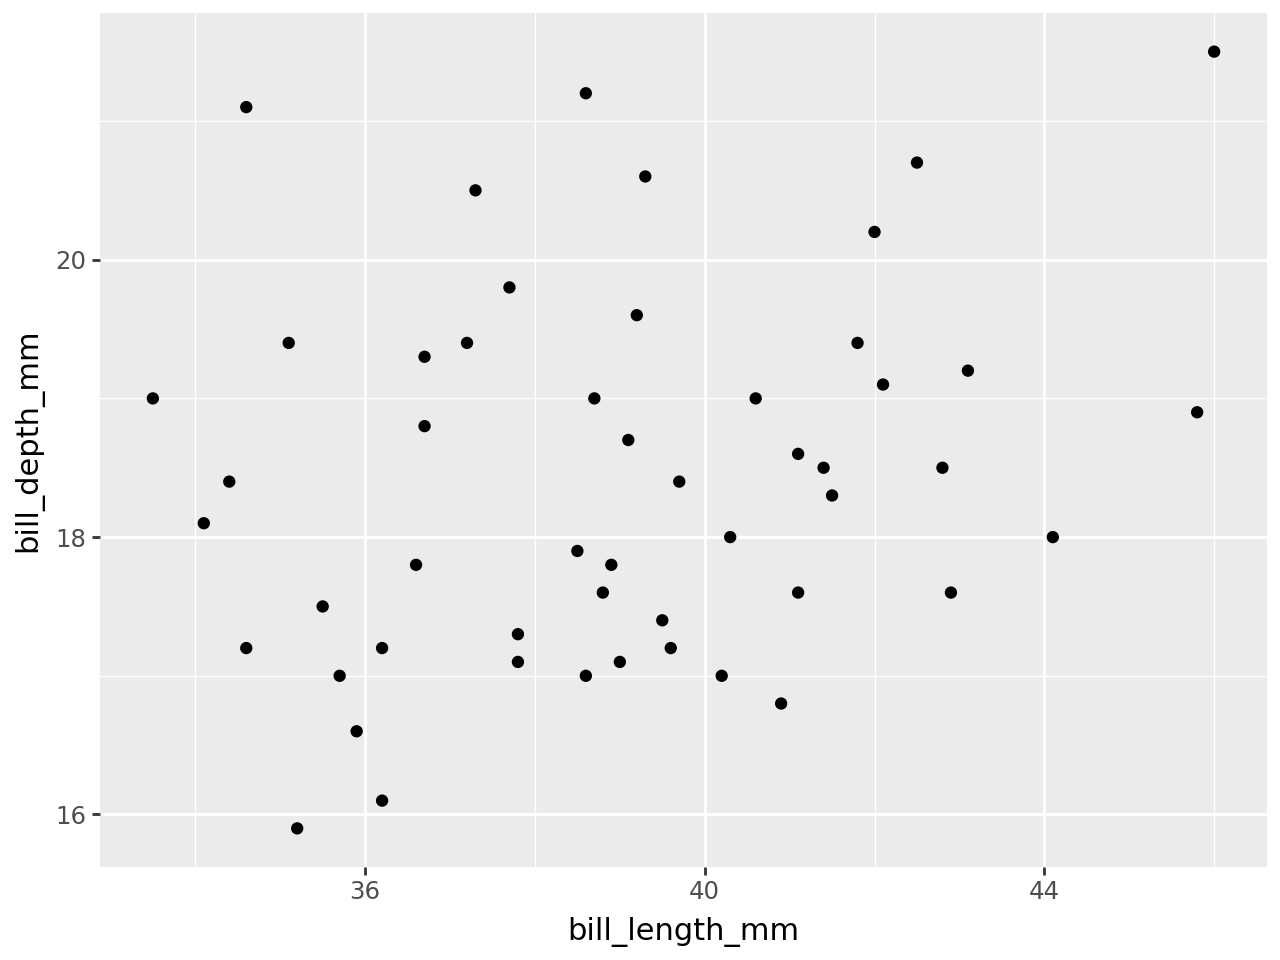

In [28]:
#dynamic
species_choice = "Adelie"
island_choice = "Torgersen"

def penguin_plot_dynamic():
    df = load_penguins()

    if species_choice:
        df = df[df["species"] == species_choice]

    if island_choice:
        df = df[df["island"] == island_choice]

    plot = (ggplot(df, aes(x = "bill_length_mm", y = "bill_depth_mm")) + geom_point())

    return plot

penguin_plot_dynamic()

1. Fill in the necessary code to write a function called `times_seven()`. The function should take a single argument (`x`) and multiply the input by 7.
  + This function should check that the argument is numeric.
  + This function should also excitedly announce (print) *“I love sevens!”* if the argument to the function is a 7.

In [29]:
def times_seven(x):

    if not isinstance(x, (int, float)):
        exit("x must be numeric")

    if x == 7:
        print("I love sevens!")

    return x * 7

2. Write and run some *unit tests* for your `times_seven` function.  What happens if the input to the function is `[1, 3, 5, 7]`?

In [30]:
times_seven(1)

7

In [31]:
times_seven(3)

21

In [32]:
times_seven(5)

35

In [33]:
times_seven(7)

I love sevens!


49

In [34]:
assert times_seven(1) == 7
assert times_seven(3) == 21
assert times_seven(5) == 35
assert times_seven(7) == 49

I love sevens!


In [35]:
times_seven([1, 3, 5, 7])

SystemExit: x must be numeric

/usr/local/lib/python3.13/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.


The function doesn't accept [1, 3, 5, 7] b/c the input is a list.

3. Consider the following function:

In [ ]:
def add_or_subtract(first_num, second_num = 2, type = "add"):

  if (type == "add"):
    res = first_num + second_num
  elif (type == "subtract"):
    res = first_num - second_num
  else:
    exit("Please choose `add` or `subtract` as the type.")

    return res

**Without running the code**, predict if the following will produce:

a. 1

b. -1

c. 30

d. An error defined by the function `add_or_subtract()`

e. An error defined in a different function, which is called inside the `add_or_subtract()` function

Predictions:

add_or_subtract(5, 6, type = "subtract")

b. -1

add_or_subtract("orange")

e. An error defined in a different function, which is called inside add_or_subtract()

add_or_subtract(5, 6, type = "multiply")

d. An error defined by the function add_or_subtract()

5 - 6 = -1; "orange" + 2 causes Python's own type error

"multiply" isn't one of the function's allowed choices, so it reaches the custom exit() message.

In [ ]:
add_or_subtract(5, 6, type = "subtract")

add_or_subtract("orange")

add_or_subtract(5, 6, type = "multiply")

In [ ]:
add_or_subtract(5, 6, type = "multiply")

4. Consider the following code:

In [ ]:
first_num  = 5
second_num = 3

result = 8

result = add_or_subtract(first_num, second_num = 4)

result_2 = add_or_subtract(first_num)


In your Global Environment, what is the value of...

a. `first_num`

b. `second_num`

c. `result`

d. `result_2`

a. first_num = 5
b. second_num = 3
c. result = 9
d. result_2 = 7

result = 8 gets overwritten by add_or_subtract(first_num, second_num=4). Since type defaults to "add", that's 5 + 4 = 9.

result_2 = add_or_subtract(first_num) uses the default second_num = 2, so 5 + 2 = 7.

The function arguments don't change the global variables, so first_num stays 5 and second_num stays 3.